# Cədvələ ümumi baxış

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('youtube_shorts_performance_dataset.csv')
pd.DataFrame(df)

,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech
...,...,...,...,...,...,...,...,...,...,...
295,vid_1295,Short Video #295,15,3,248940,23810,488,1247,12,Tech
296,vid_1296,Short Video #296,32,4,366340,29586,46,1548,8,Travel
297,vid_1297,Short Video #297,29,3,434027,6471,3359,1069,21,Comedy
298,vid_1298,Short Video #298,54,4,318623,6459,4873,1690,14,Food


# Describe ilə cədvəldə ümumi baxış və Kateqoriyalar üzrə orta performans

In [130]:
def format_number(x):
    if x >= 1_000_000_000:
        return f"{x/1_000_000_000:.1f}B"
    elif x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.1f}K"
    else:
        return f"{x:.0f}"
        
print("~Cədvəl Statistikaları~")
stats = df[['duration_sec', 'views', 'likes', 'comments', 'shares']].describe().round(1)
formatted_stats = stats.copy()
for col in formatted_stats.columns:
    formatted_stats[col] = formatted_stats[col].map(format_number)
    
print("\nƏsas Rəqəmlər Üzrə Ümumi Məlumat:")
display(formatted_stats)

category_performance = df.groupby('category')[['views', 'likes', 'shares']].mean().sort_values(by='views', ascending=False)

formatted_category = category_performance.copy()
for col in formatted_category.columns:
    formatted_category[col] = formatted_category[col].map(format_number)

print("\nKateqoriyalar üzrə Orta Performans:")
display(formatted_category)

~Cədvəl Statistikaları~

Əsas Rəqəmlər Üzrə Ümumi Məlumat:


,duration_sec,views,likes,comments,shares
count,300,300,300,300,300
mean,32,245.1K,23.1K,2.6K,1000
std,16,141.3K,14.6K,1.4K,564
min,5,1.4K,109,40,2
25%,18,129.6K,10.3K,1.4K,516
50%,32,256.0K,21.8K,2.9K,988
75%,45,356.8K,36.7K,3.8K,1.5K
max,59,499.4K,49.9K,5.0K,2.0K



Kateqoriyalar üzrə Orta Performans:


,views,likes,shares
category,,,
Lifestyle,277.5K,23.8K,967
Comedy,271.9K,25.9K,1.1K
Travel,246.9K,20.7K,987
Food,234.8K,23.0K,901
Education,224.5K,24.9K,1.0K
Tech,223.6K,19.7K,993


# Kateqoriyalara görə ən çox paylaşılanlar

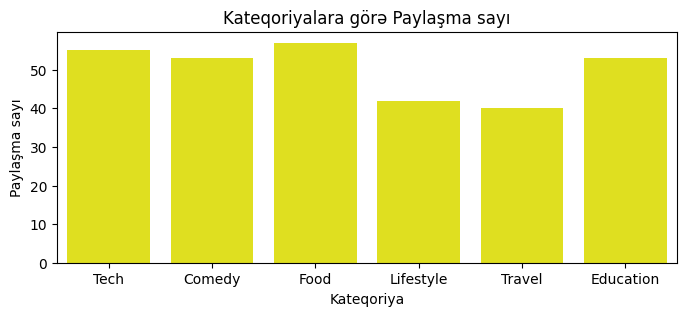

In [186]:
plt.figure(figsize=(8,3))
sns.countplot(x="category", data=df, color='yellow')
plt.title("Kateqoriyalara görə Paylaşma sayı")
plt.xlabel("Kateqoriya")
plt.ylabel("Paylaşma sayı")
plt.show()


# Videonun uzunluğuna görə kateqoriyalar üzrə izlənmə sayı

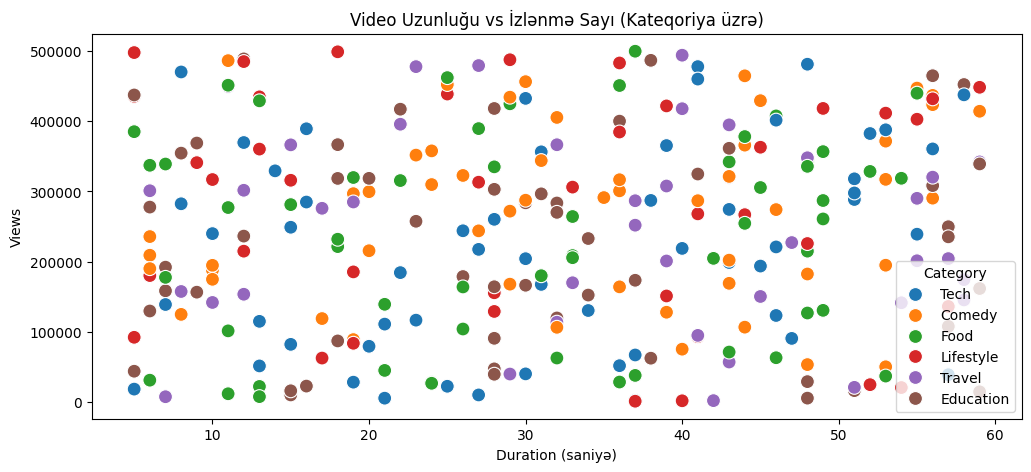

In [184]:
plt.figure(figsize=(12,5))
sns.scatterplot(data=df, x='duration_sec', y='views', hue='category', s=100)
plt.title("Video Uzunluğu vs İzlənmə Sayı (Kateqoriya üzrə)")
plt.xlabel("Duration (saniyə)")
plt.ylabel("Views")
plt.legend(title="Category")
plt.show()

# Kateqoriyalara görə ən çox izlənmələr

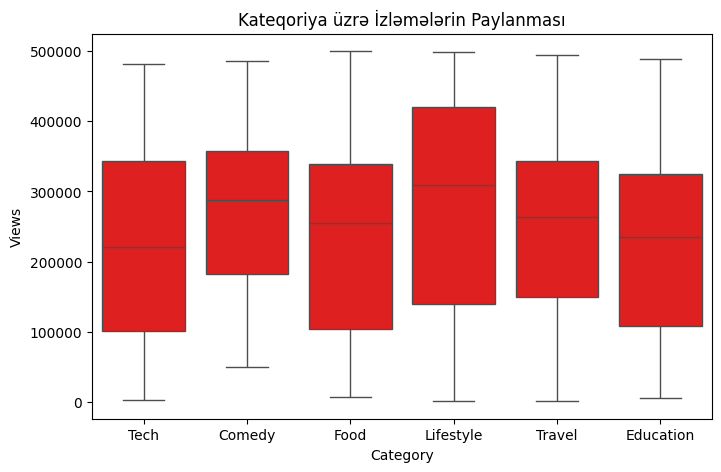

In [183]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='category', y='views', color='red')
plt.title("Kateqoriya üzrə İzləmələrin Paylanması")
plt.xlabel("Category")
plt.ylabel("Views")
plt.show()


# Kateqoriyaya görə izlımələrin paylanılması

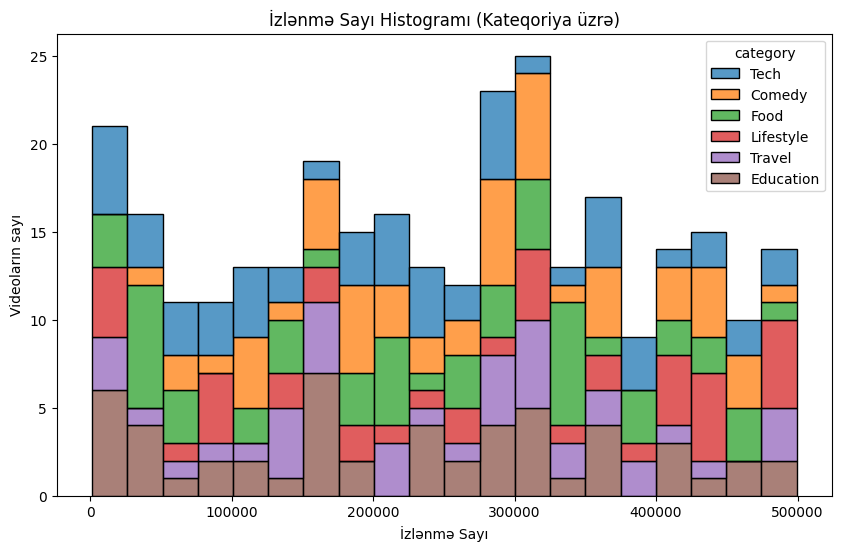

In [185]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df, 
    x='views', 
    hue='category', 
    multiple='stack',
    bins=20)
plt.title("İzlənmə Sayı Histogramı (Kateqoriya üzrə)")
plt.xlabel("İzlənmə Sayı")
plt.ylabel("Videoların sayı")
plt.show()

# Ədədi olan dəyişənlər arasındakı korelasiya heatmap

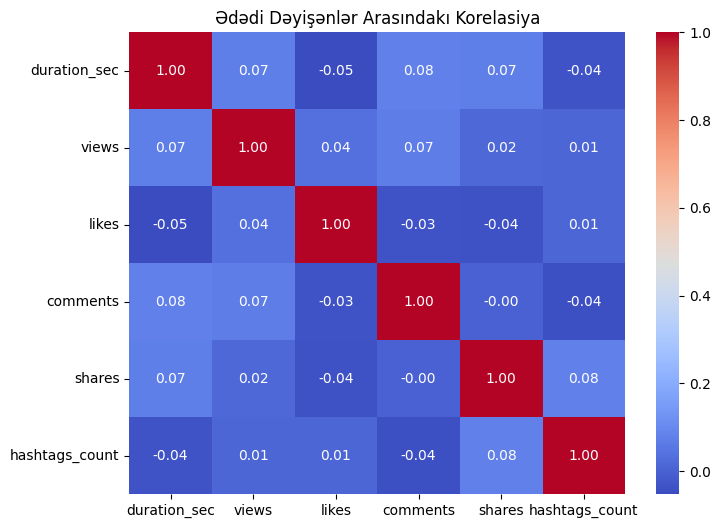

In [4]:
cols = ['duration_sec', 'views', 'likes', 'comments', 'shares', 'hashtags_count']

matrix = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, fmt=".2f",  cmap="coolwarm", cbar=True)
plt.title("Ədədi Dəyişənlər Arasındakı Korelasiya")
plt.show()

# Videoların kateqoriyalarına görə bəyənmələr və şərhlər

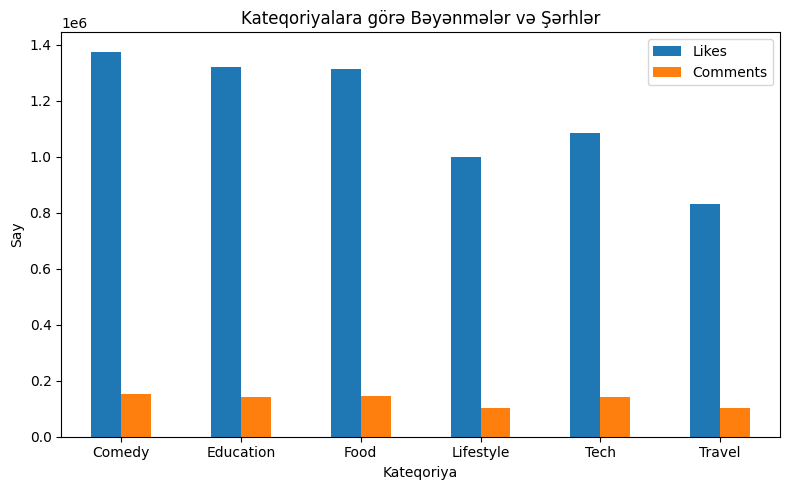

In [5]:
category_stats = df.groupby("category")[["likes", "comments"]].sum()
category_stats.plot(kind="bar", figsize=(8,5))
plt.title("Kateqoriyalara görə Bəyənmələr və Şərhlər")
plt.xlabel("Kateqoriya")
plt.ylabel("Say")
plt.xticks(rotation=0)
plt.legend(["Likes", "Comments"])
plt.tight_layout()
plt.show()

# Paylaşım saatına görə izlənmələr

<Axes: xlabel='upload_hour'>

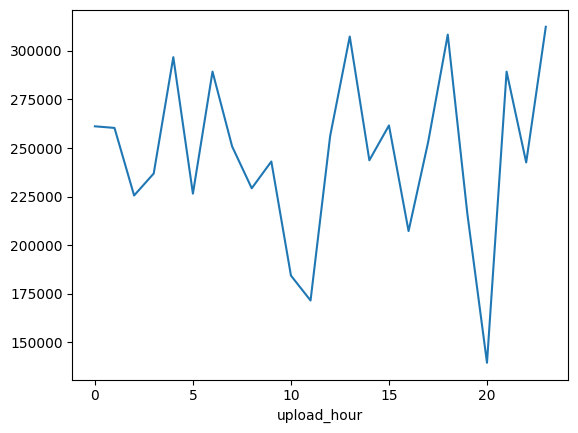

In [8]:
df.groupby("upload_hour")["views"].mean()
df.groupby("upload_hour")["views"].mean().plot(kind="line")

# Top 10

In [11]:
df.sort_values("views", ascending=False).head(10)


,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
272,vid_1272,Short Video #272,37,6,499401,22051,4197,132,21,Food
150,vid_1150,Short Video #150,18,7,498562,38210,4277,1130,13,Lifestyle
146,vid_1146,Short Video #146,5,5,497484,35458,2538,1266,23,Lifestyle
85,vid_1085,Short Video #85,40,2,493734,1631,2713,696,2,Travel
64,vid_1064,Short Video #64,12,0,488462,402,574,738,13,Education
102,vid_1102,Short Video #102,29,7,487261,48015,2482,375,6,Lifestyle
266,vid_1266,Short Video #266,38,6,486450,41257,3569,355,3,Education
46,vid_1046,Short Video #46,11,7,486008,43028,1792,38,18,Comedy
131,vid_1131,Short Video #131,12,9,484685,3912,1823,10,20,Lifestyle
256,vid_1256,Short Video #256,36,9,482680,2292,153,570,16,Lifestyle


# Worst 10

In [13]:
df.sort_values("views").head(10)


,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
203,vid_1203,Short Video #203,37,3,1404,27634,804,1355,5,Lifestyle
180,vid_1180,Short Video #180,40,6,2015,13041,2679,2,11,Lifestyle
262,vid_1262,Short Video #262,42,2,2252,26827,938,556,3,Travel
27,vid_1027,Short Video #27,37,5,2542,33534,3281,1513,21,Tech
68,vid_1068,Short Video #68,21,2,5748,8817,385,250,2,Tech
219,vid_1219,Short Video #219,48,7,5809,5356,454,1924,22,Education
17,vid_1017,Short Video #17,7,3,7801,6338,3205,726,3,Travel
273,vid_1273,Short Video #273,13,8,7949,15474,2322,1770,11,Food
137,vid_1137,Short Video #137,27,5,10337,6867,2490,563,10,Tech
11,vid_1011,Short Video #11,15,6,10348,45102,1834,136,9,Education


# Videolar üzrə qarşılıqlı əlaqə göstəricisi

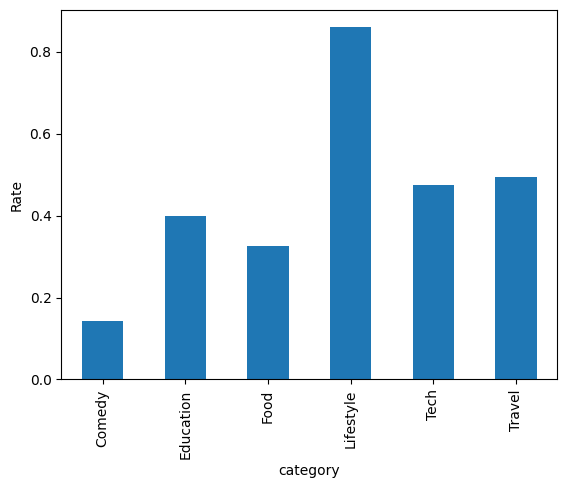

In [18]:
df["rate"] = (df["likes"] + df["comments"] + df["shares"]) / df["views"]
df.groupby("category")["rate"].mean().sort_values(ascending=False)
df.groupby("category")["rate"].mean().plot(kind="bar")
plt.ylabel("Rate")
plt.show()

# Paylaşım saatına görə videolar üzrə qarşılıqlı əlaqə göstəricisi

In [21]:
pivot = df.pivot_table( values="rate",
    index="upload_hour",
    columns="category",
    aggfunc="mean")
pivot


category,Comedy,Education,Food,Lifestyle,Tech,Travel
upload_hour,,,,,,
0,0.100242,0.129905,NaN,0.591945,0.155165,NaN
1,0.099318,0.086624,0.472187,0.188631,0.337834,0.042858
2,0.276021,0.072149,0.171262,0.242915,0.710446,0.010208
3,0.142796,0.155566,NaN,0.119611,0.069093,2.824044
4,0.122090,0.102424,0.124638,0.023668,0.282466,NaN
5,0.077186,0.428432,0.064360,10.655405,0.165847,0.106762
6,0.114999,0.415059,0.103349,0.101327,0.142259,0.039462
7,0.235581,0.080428,0.537197,NaN,0.205211,NaN
8,0.089500,0.022377,0.799690,0.296920,0.085489,0.154283


# Kateqoriyalar üzrə Bəyənmə və Şərh nisbətlərinin izlənmələrə görə əlaqəsi

In [25]:
df["like_view"] = df["likes"] / df["views"]
df["comment_view"] = df["comments"] / df["views"]
df.groupby("category")[["like_view","comment_view"]].mean()
netice = df.groupby("category")[["like_view", "comment_view"]].mean().round(2)
netice

,like_view,comment_view
category,,
Comedy,0.12,0.01
Education,0.35,0.03
Food,0.28,0.03
Lifestyle,0.77,0.06
Tech,0.40,0.05
Travel,0.44,0.03
